# Classifição - Machine Learning

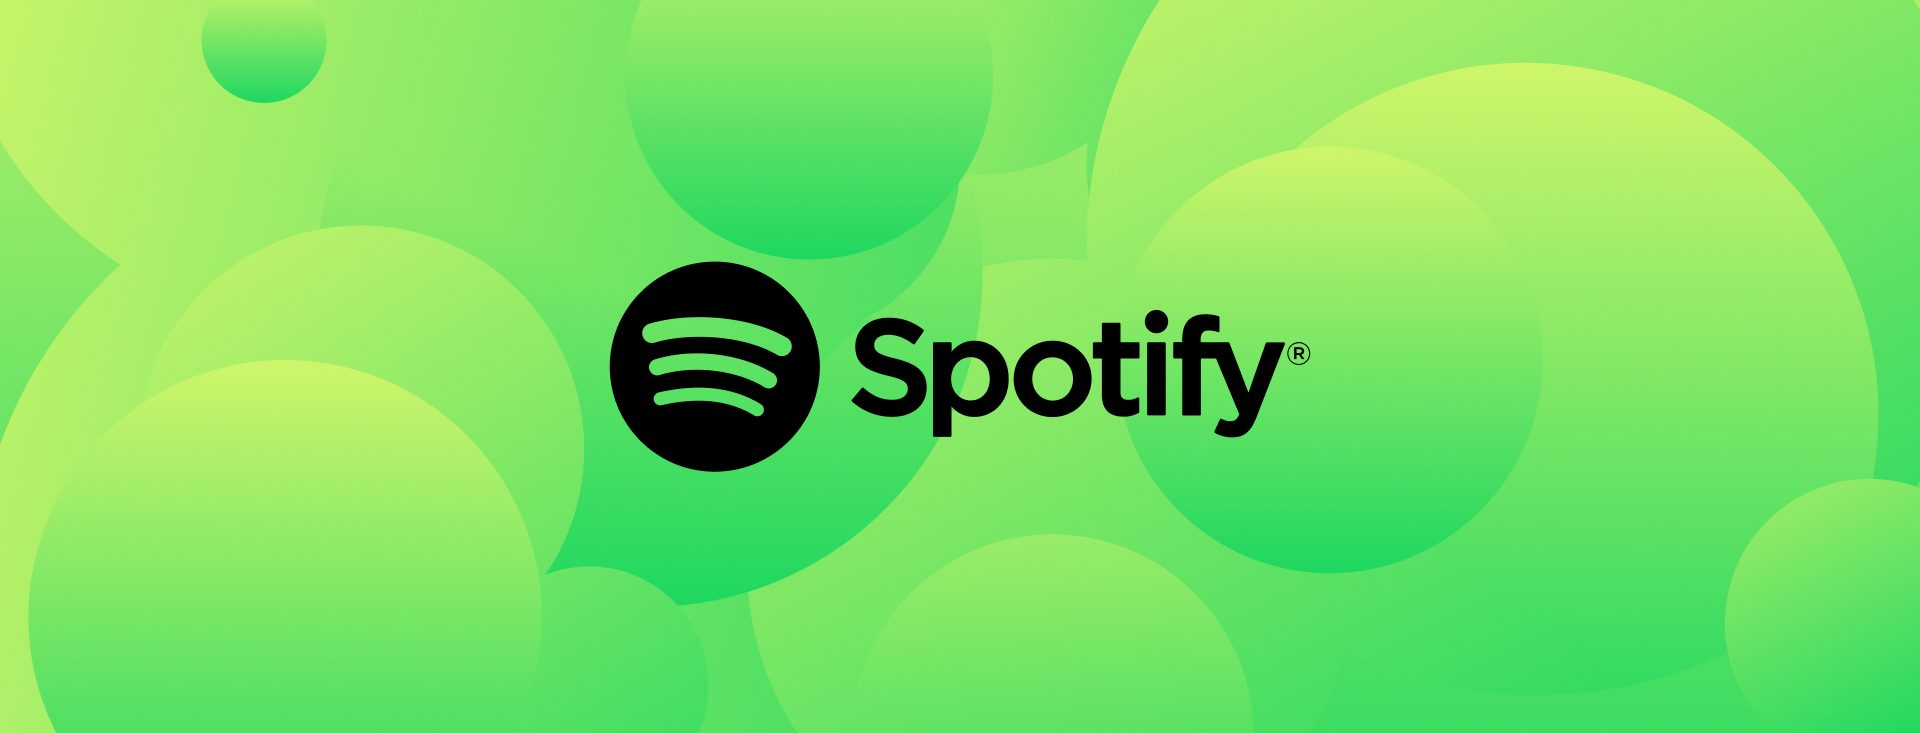

## Análise exploratória de dados - Distribuição do target

In [40]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
path_90 = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify"
path_00 = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify"
path_10 = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify"


In [10]:
f"{path_90}/dataset-of-90s.csv"

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify/dataset-of-90s.csv'

In [11]:
f"{path_00}/dataset-of-00s.csv"

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify/dataset-of-00s.csv'

In [12]:
f"{path_10}/dataset-of-10s.csv"

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Classificacao/Classificacao-main/Datasets/The Spotify/dataset-of-10s.csv'

In [14]:
df_90 = pd.read_csv(f"{path_90}/dataset-of-90s.csv")
df_00 = pd.read_csv(f"{path_00}/dataset-of-00s.csv")
df_10 = pd.read_csv(f"{path_10}/dataset-of-10s.csv")

In [15]:
df = pd.concat([df_90, df_00, df_10])

In [16]:
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Misty Roses,Astrud Gilberto,spotify:track:50RBM1j1Dw7WYmsGsWg9Tm,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.00699,0.1680,0.543,116.211,158840,4,53.89523,6,0
1,Never Ever,All Saints,spotify:track:5FTz9qQ94PyUHETyAyfYZN,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.00000,0.0492,0.309,134.187,387573,4,32.16853,16,1
2,Soul Sermon,Gregg Karukas,spotify:track:6m24oe3lk1UMxq9zq4iPFi,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.49500,0.0809,0.265,93.982,237267,4,42.05369,9,0
3,Clarinet Marmalade - Live,Alton Purnell,spotify:track:5FOXuiLI6knVtgMUjWKj6x,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.92600,0.6750,0.763,114.219,375933,4,80.99693,10,0
4,До смерті і довше - Drum & Base and Rock Remix,Skryabin,spotify:track:6CxyIPTqSPvAPXfrIZczs4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.00339,0.1530,0.961,153.166,430653,4,25.57331,20,0


In [17]:
df.shape

(17790, 19)

In [18]:
df["target"].isnull().sum()

np.int64(0)

In [19]:
df["target"].value_counts()

target
0    8895
1    8895
Name: count, dtype: int64

In [21]:
df["target"].value_counts(normalize=True) * 100

target
0    50.0
1    50.0
Name: proportion, dtype: float64

In [23]:
df.drop_duplicates().shape

(17617, 19)

In [25]:
df = df.drop_duplicates()

In [26]:
df["target"].value_counts()

target
0    8895
1    8722
Name: count, dtype: int64

In [27]:
df["target"].value_counts(normalize=True) * 100

target
0    50.491003
1    49.508997
Name: proportion, dtype: float64

In [32]:
df.groupby(["track", "artist"]).size().sort_values(ascending=False)

track                                    artist            
Falling                                  Julee Cruise          12
Chebika - Claudio Mate Metal Remix       Stefano Patarnello     8
Feeling Punk - Asle Remix                Todd Terry             6
Spiegel im Spiegel                       Arvo Pärt              5
Until the Day I Die                      Story Of The Year      5
                                                               ..
(Do Not Feed The) Oyster                 Stephen Malkmus        1
(Everything I Do) I Do It For You        Bryan Adams            1
(Friday Afternoon) In a Galaxy Far Away  Mattias IA Eklundh     1
(Got My) Rock Pants On                   Turing Machine         1
(Hot S**t) Country Grammar               Nelly                  1
Length: 17362, dtype: int64

In [33]:
df = df.drop_duplicates(subset=["track", "artist"])

In [34]:
df.shape

(17362, 19)

In [35]:
df["target"].value_counts(normalize=True) * 100

target
1    50.224628
0    49.775372
Name: proportion, dtype: float64

## Análise exploratória de dados - Análise das features


In [36]:
df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Misty Roses,Astrud Gilberto,spotify:track:50RBM1j1Dw7WYmsGsWg9Tm,0.527,0.316,1,-15.769,1,0.0310,0.693000,0.00699,0.1680,0.543,116.211,158840,4,53.89523,6,0
1,Never Ever,All Saints,spotify:track:5FTz9qQ94PyUHETyAyfYZN,0.738,0.541,1,-5.485,1,0.0311,0.559000,0.00000,0.0492,0.309,134.187,387573,4,32.16853,16,1
2,Soul Sermon,Gregg Karukas,spotify:track:6m24oe3lk1UMxq9zq4iPFi,0.736,0.419,0,-10.662,1,0.0300,0.693000,0.49500,0.0809,0.265,93.982,237267,4,42.05369,9,0
3,Clarinet Marmalade - Live,Alton Purnell,spotify:track:5FOXuiLI6knVtgMUjWKj6x,0.565,0.594,5,-13.086,1,0.0646,0.655000,0.92600,0.6750,0.763,114.219,375933,4,80.99693,10,0
4,До смерті і довше - Drum & Base and Rock Remix,Skryabin,spotify:track:6CxyIPTqSPvAPXfrIZczs4,0.513,0.760,4,-10.077,1,0.0355,0.000017,0.00339,0.1530,0.961,153.166,430653,4,25.57331,20,0


In [37]:
df.dtypes

track                object
artist               object
uri                  object
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature        int64
chorus_hit          float64
sections              int64
target                int64
dtype: object

In [38]:
df.isnull().sum()

track               0
artist              0
uri                 0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
dtype: int64

In [39]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
count,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,17362.000000,1.736200e+04,17362.000000,17362.000000,17362.000000,17362.000000
mean,0.559860,0.655534,5.269036,-8.368586,0.652632,0.088807,0.240249,0.157978,0.196683,0.485989,121.053226,2.494776e+05,3.923050,40.964088,10.795473,0.502246
std,0.187469,0.246079,3.563331,5.302304,0.476148,0.092832,0.307832,0.308222,0.167195,0.255124,29.909889,1.119149e+05,0.378197,19.964160,4.744401,0.500009
min,0.057600,0.000251,0.000000,-49.253000,0.000000,0.022000,0.000000,0.000000,0.013000,0.000000,34.535000,1.592000e+04,0.000000,0.000000,1.000000,0.000000
25%,0.438000,0.505000,2.000000,-9.919000,0.000000,0.035700,0.009080,0.000000,0.093800,0.278250,97.149000,1.997632e+05,4.000000,27.902563,8.000000,0.000000
50%,0.577000,0.699000,5.000000,-6.913500,1.000000,0.050400,0.082700,0.000044,0.128000,0.487000,119.876000,2.331265e+05,4.000000,36.271890,10.000000,1.000000
75%,0.697000,0.856000,8.000000,-5.036000,1.000000,0.096700,0.378750,0.058800,0.257000,0.690000,140.003000,2.763132e+05,4.000000,48.324433,12.000000,1.000000
max,0.986000,0.999000,11.000000,1.137000,1.000000,0.956000,0.996000,0.998000,0.992000,0.996000,217.872000,4.170227e+06,5.000000,262.615400,169.000000,1.000000


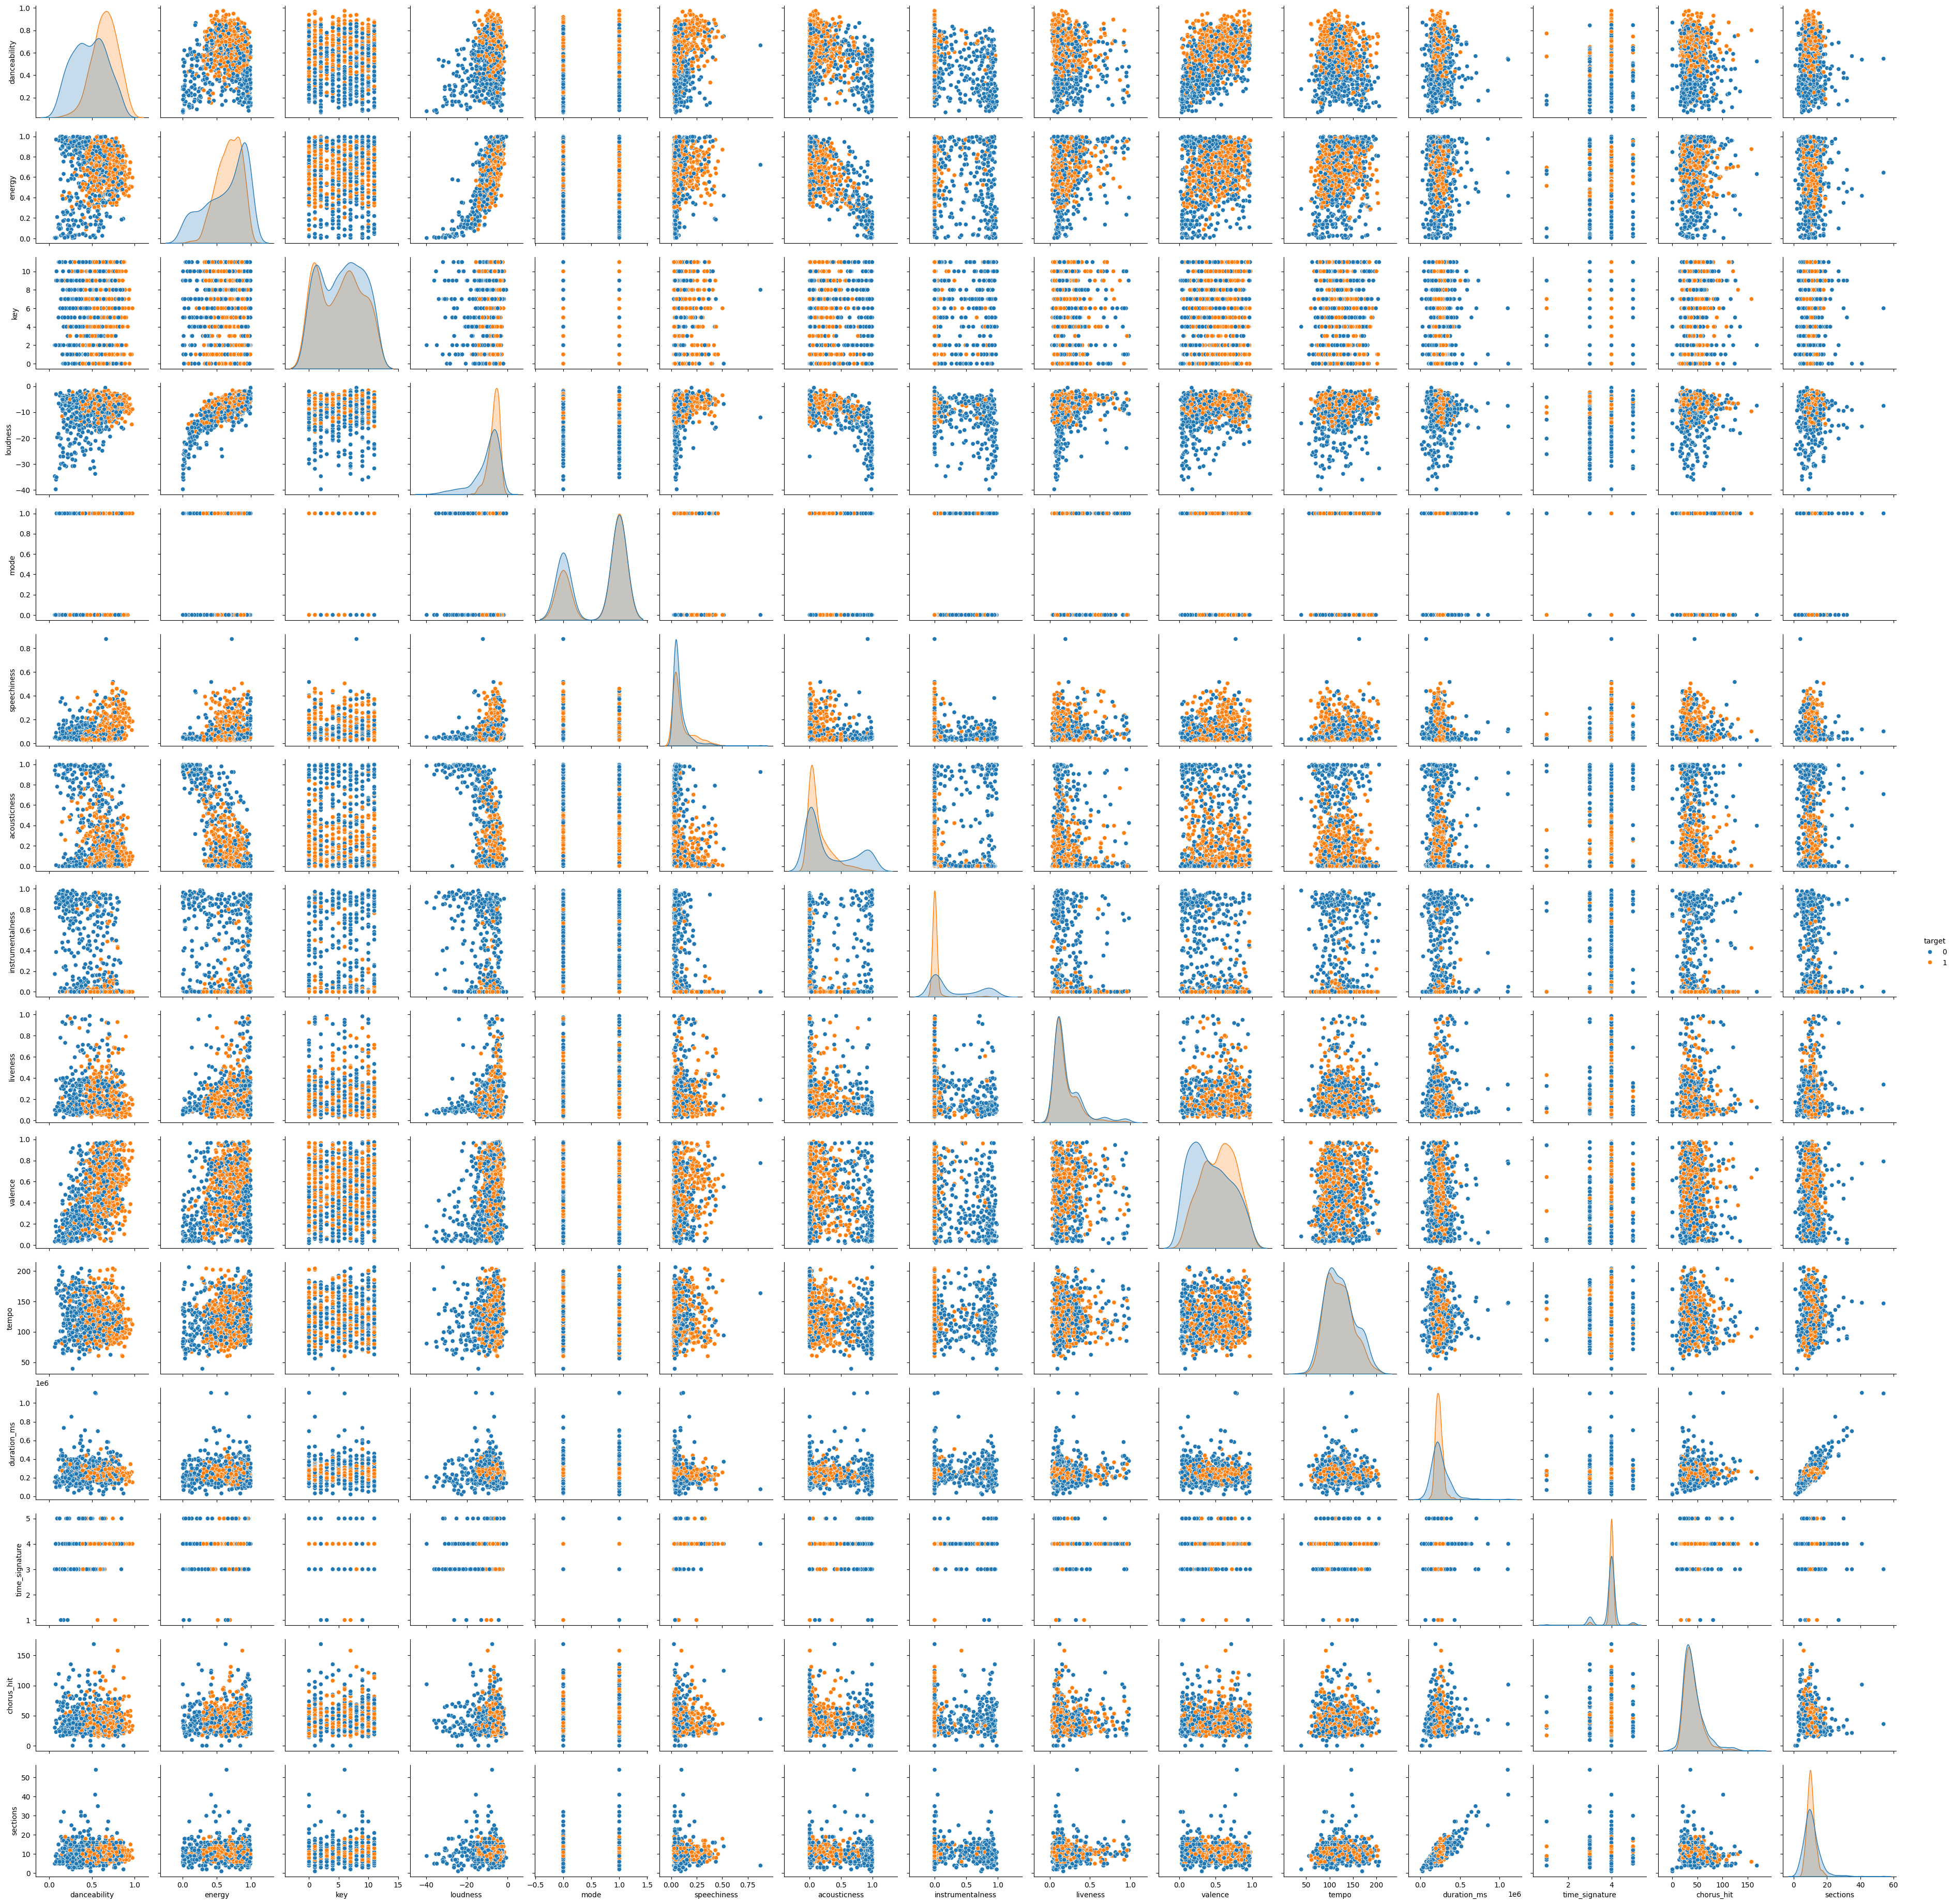

In [42]:
sns.pairplot(df.sample(1000), hue="target")

In [43]:
corr = df.select_dtypes('number').corr()

In [44]:
corr

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
danceability,1.000000,0.079547,0.020302,0.267515,-0.056397,0.187636,-0.194841,-0.349111,-0.109281,0.535457,-0.118716,-0.115242,0.177744,-0.066383,-0.090907,0.431556
energy,0.079547,1.000000,0.021120,0.773543,-0.008728,0.131180,-0.733336,-0.249619,0.201618,0.291144,0.206553,-0.088570,0.172705,-0.006720,-0.132499,0.117765
key,0.020302,0.021120,1.000000,0.007618,-0.153838,0.027905,-0.022199,-0.017270,-0.002199,0.019862,-0.003238,0.009676,-0.002717,0.003174,0.001698,0.018331
loudness,0.267515,0.773543,0.007618,1.000000,0.016656,0.114683,-0.641656,-0.453169,0.105401,0.279348,0.166995,-0.131400,0.181857,-0.037466,-0.152349,0.325587
mode,-0.056397,-0.008728,-0.153838,0.016656,1.000000,-0.078042,0.021148,-0.052902,0.003108,-0.001089,0.024613,-0.049147,0.009249,-0.020418,-0.037367,0.037270
speechiness,0.187636,0.131180,0.027905,0.114683,-0.078042,1.000000,-0.106344,-0.125366,0.137592,0.072458,0.037671,-0.029736,0.037711,-0.003131,-0.020936,0.070972
acousticness,-0.194841,-0.733336,-0.022199,-0.641656,0.021148,-0.106344,1.000000,0.282381,-0.097353,-0.177628,-0.159021,0.051123,-0.178735,0.009614,0.093083,-0.260632
instrumentalness,-0.349111,-0.249619,-0.017270,-0.453169,-0.052902,-0.125366,0.282381,1.000000,-0.039401,-0.296400,-0.040159,0.138729,-0.113558,0.082667,0.099897,-0.467519
liveness,-0.109281,0.201618,-0.002199,0.105401,0.003108,0.137592,-0.097353,-0.039401,1.000000,-0.010216,0.034006,0.000114,0.017876,0.045560,-0.024413,-0.081944
valence,0.535457,0.291144,0.019862,0.279348,-0.001089,0.072458,-0.177628,-0.296400,-0.010216,1.000000,0.039768,-0.174687,0.140427,-0.070973,-0.130453,0.214187


<Axes: >

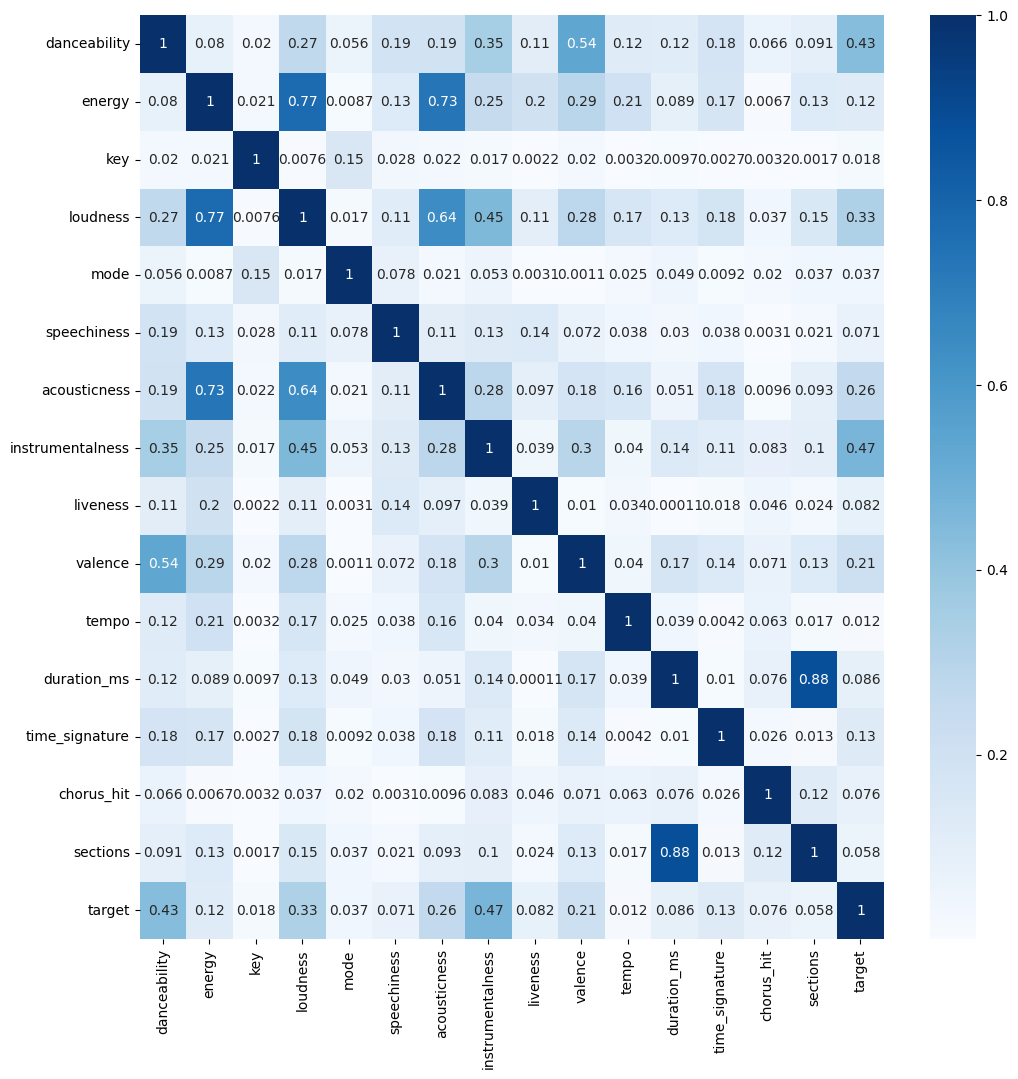

In [49]:
fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(corr.abs(), cmap="Blues", annot=True)